In [3]:
import pandas as pd

df = pd.read_excel("/content/scheduled_tribes_aba.xlsx")
print(df.head())

  Country                              Year  \
0   India  Financial Year (Apr - Mar), 2024   
1   India  Financial Year (Apr - Mar), 2024   
2   India  Financial Year (Apr - Mar), 2024   
3   India  Financial Year (Apr - Mar), 2024   
4   India  Financial Year (Apr - Mar), 2024   

                                 Name Of The Schemes    Additional Info  \
0                   Schemes of North Eastern Council  As on 31-Dec-2024   
1  North East Special Infrastructure Development ...  As on 31-Dec-2024   
2  Prime Minister's Development Initiative for No...  As on 31-Dec-2024   
3  Special Package for Bodoland Territorial Counc...  As on 31-Dec-2024   
4  Special Package for Karbi Anglong Territorial ...  As on 31-Dec-2024   

   Total Outlay As Per Budget Estimates (Be) (UOM:INR(IndianRupees)), Scaling Factor:10000000  \
0                                                NaN                                            
1                                                NaN                    

In [6]:
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

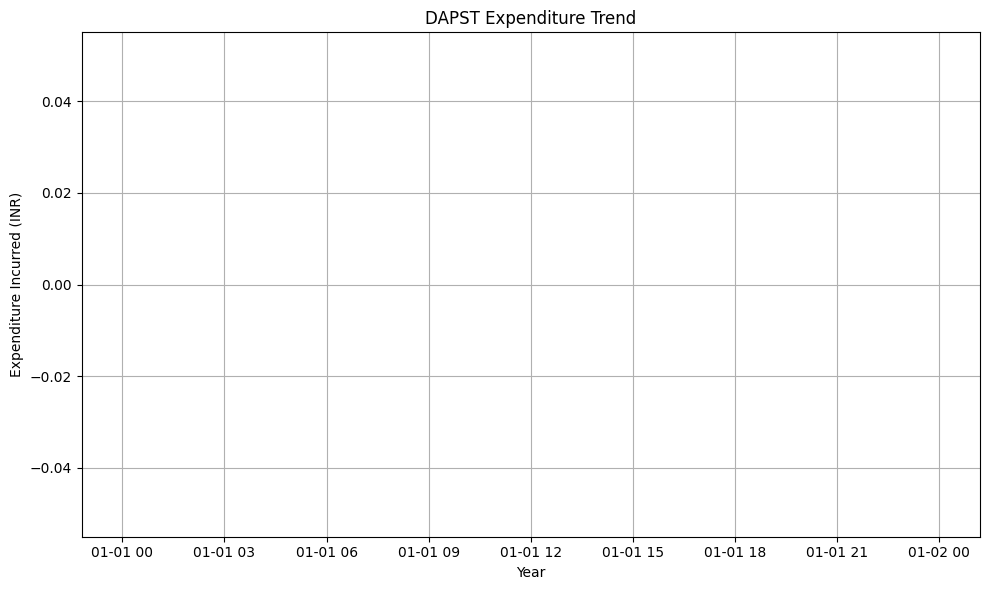

In [8]:
import matplotlib.pyplot as plt

expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

# Create a subset of the DataFrame for plotting, dropping NaNs only in relevant columns
df_plot = df.dropna(subset=['Year', expenditure_column])

plt.figure(figsize=(10, 6))
plt.plot(df_plot['Year'], df_plot[expenditure_column])
plt.title("DAPST Expenditure Trend")
plt.xlabel("Year")
plt.ylabel("Expenditure Incurred (INR)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

# Create a temporary DataFrame for regression, converting Year to numerical and dropping NaNs
df_regression = df.dropna(subset=['Year', expenditure_column]).copy()
df_regression['Year_numeric'] = df_regression['Year'].dt.year

X = df_regression[['Year_numeric']]
y = df_regression[expenditure_column]

# Check if the DataFrame for regression is empty
if df_regression.empty:
    print("Cannot perform linear regression: No valid data points found after dropping missing values.")
else:
    model = LinearRegression()
    model.fit(X, y)

    print("Trend Coefficient:", model.coef_)

Cannot perform linear regression: No valid data points found after dropping missing values.


In [13]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd # Ensure pandas is imported if not already

expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

# Create a temporary DataFrame for regression, converting Year to numerical and dropping NaNs
df_rf = df.copy()

# Ensure 'Year' is a datetime object (as per cell uFnRXVVFq2p-)
# df_rf['Year'] = pd.to_datetime(df_rf['Year'], format='%Y') # This is already done in uFnRXVVFq2p-

df_rf['Year_numeric'] = df_rf['Year'].dt.year

# Drop rows with NaN values in the relevant columns
df_rf = df_rf.dropna(subset=['Year_numeric', expenditure_column])

X = df_rf[['Year_numeric']]
y = df_rf[expenditure_column]

# Check if the DataFrame for RF regression is empty
if df_rf.empty or X.empty or y.empty:
    print("Cannot perform Random Forest Regression: No valid data points found after dropping missing values.")
else:
    rf = RandomForestRegressor(random_state=42) # Add random_state for reproducibility
    rf.fit(X, y)

    pred = rf.predict(X)
    print("Random Forest Regression successful. First 5 predictions:", pred[:5])


Cannot perform Random Forest Regression: No valid data points found after dropping missing values.


In [17]:
import streamlit as st
import pandas as pd

# Re-load the DataFrame from the original Excel file since the kernel state shows df is empty
df = pd.read_excel("/content/scheduled tribes aba .xlsx")

# Re-process the Year column as done previously
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# Define the correct expenditure column name
expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

st.title("DAPST Expenditure Analysis")

# Ensure only unique years are shown in the selectbox
year_options = sorted(df['Year'].unique())
year = st.selectbox("Select Year", year_options)

filtered_df = df[df['Year'] == year]

st.write(f"### Data for Year: {year}")
st.dataframe(filtered_df)

# Ensure the data for line chart is prepared correctly
# Aggregate expenditure by year for the line chart
expenditure_by_year = df.groupby('Year')[expenditure_column].sum().reset_index()

# Rename the column to an Altair-friendly name for plotting
expenditure_by_year.rename(columns={expenditure_column: 'Total Expenditure'}, inplace=True);
expenditure_by_year = expenditure_by_year.sort_values('Year')

st.write("### Total Expenditure Trend Over Years")
st.line_chart(expenditure_by_year.set_index('Year')['Total Expenditure'])


2026-04-22 19:38:08.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.524 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.537 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-22 19:38:08.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd

# Re-load the DataFrame from the original Excel file since the kernel state shows df is empty
df = pd.read_excel("/content/scheduled tribes aba .xlsx")

# Re-process the Year column as done previously
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# Define the correct expenditure column name
expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

st.title("DAPST Expenditure Analysis")

# Ensure only unique years are shown in the selectbox
year_options = sorted(df['Year'].unique())
year = st.selectbox("Select Year", year_options)

filtered_df = df[df['Year'] == year]

st.write(f"### Data for Year: {year}")
st.dataframe(filtered_df)

# Ensure the data for line chart is prepared correctly
# Aggregate expenditure by year for the line chart
expenditure_by_year = df.groupby('Year')[expenditure_column].sum().reset_index()

# Rename the column to an Altair-friendly name for plotting
expenditure_by_year.rename(columns={expenditure_column: 'Total Expenditure'}, inplace=True);
expenditure_by_year = expenditure_by_year.sort_values('Year')

st.write("### Total Expenditure Trend Over Years")
st.line_chart(expenditure_by_year.set_index('Year')['Total Expenditure'])


Writing app.py


In [20]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.89.31:8501

  Stopping...
^C


In [15]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd

st.title("DAPST Analysis")

# Correct file loading
df = pd.read_excel("scheduled_tribes_aba.xlsx")

st.write(df.head())

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.89.31:8501

